# Task 4 — Step 2: Post-hoc Novelty Scores on the Frozen Vanilla Model

Every method is written as an **unknownness score** $u(x)$ (larger = more novel), with $p_k=\operatorname{softmax}(z)_k$:

| Score | Definition | Signal |
|---|---|---|
| MSP | $1-\max_k p_k(x)$ | normalised confidence |
| MLS | $-\max_k z_k(x)$ | absolute logit magnitude |
| Energy | $-\log\sum_k e^{z_k(x)}$ | evidence summed over all logits |
| Mahalanobis | $\min_c (f-\mu_c)^\top\Sigma^{-1}(f-\mu_c)$ | distance to the nearest known-class cluster in feature space |

Mahalanobis uses class means $\mu_c$ and **one shared diagonal** covariance $\Sigma$ from *unaugmented* CIFAR-10 training features, with $10^{-6}$ added to every diagonal entry. All four scores use exactly the same saved logits and features.

**Operating point.** $\tau$ = 95th percentile of $u$ on CIFAR-10 **validation**; accept iff $u\le\tau$. Reported: AUROC (Known vs Near / Far / All), known-test acceptance, near/far rejection, FPR@95TPR (= fraction of unknowns accepted at $\tau$).

**Ordering.** This is the first notebook that loads CIFAR-100. The cell below checks that Vanilla, GCSC and PROSER are already trained, i.e. every checkpoint and score definition is fixed before any unknown is seen.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if not os.path.isdir(os.path.join(ROOT, 'task4_open_set')) and os.path.isdir('/content/task4_open_set'):
    ROOT = '/content'                    # running on a Colab server (see 0_colab_setup.ipynb)
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from shared.src.seed import set_seed, SEED
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, GROUP_COLORS, NEUTRAL, INK_2, color_of, save_show
from shared.src.diagrams import osr_pipeline_diagram
from sklearn.manifold import TSNE
from task4_open_set.src.data import get_cifar100_unknowns, make_loader, CIFAR10_CLASSES, NEAR_UNKNOWNS, FAR_UNKNOWNS, MEAN, STD, denorm
from task4_open_set.src.resnet_cifar import ResNetCIFAR
from task4_open_set.src.train import extract_outputs
from task4_open_set.src.scores import fit_mahalanobis, all_posthoc_scores
from task4_open_set.src.evaluate import osr_report, roc, per_class_auroc

use_style()
set_seed(SEED)
device = torch.device('cuda')
T4 = os.path.join(ROOT, 'task4_open_set')
CKPT, CACHE, RES = [os.path.join(T4, d) for d in ('checkpoints', 'cache', 'results')]
for m in ['vanilla', 'gcsc', 'proser']:
    assert os.path.exists(os.path.join(CKPT, f'{m}.pth')), f'{m} must be trained before unknowns are evaluated'
print('all checkpoints fixed -> unknown evaluation allowed')

all checkpoints fixed -> unknown evaluation allowed


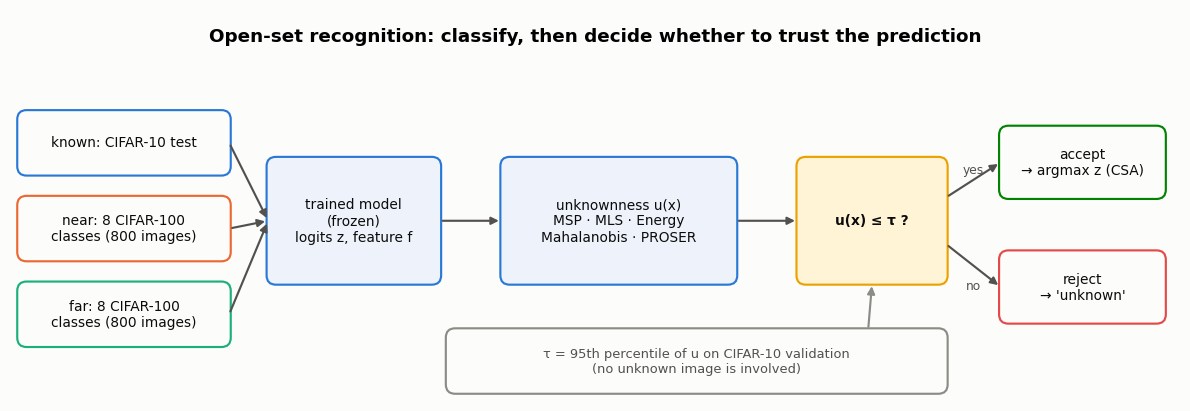

In [2]:
fig = osr_pipeline_diagram()
save_show(fig, os.path.join(RES, 'osr_pipeline_diagram.png'))

## 1. The fixed unknown groups (CIFAR-100 test split only)
Download CIFAR-100 (~161 MB, official archive from www.cs.toronto.edu, into `data/cifar100/`; skipped if already present). The archive contains both splits, but only the **test** split is ever loaded, and only the 16 fixed classes.

near: 800 images, far: 800 images


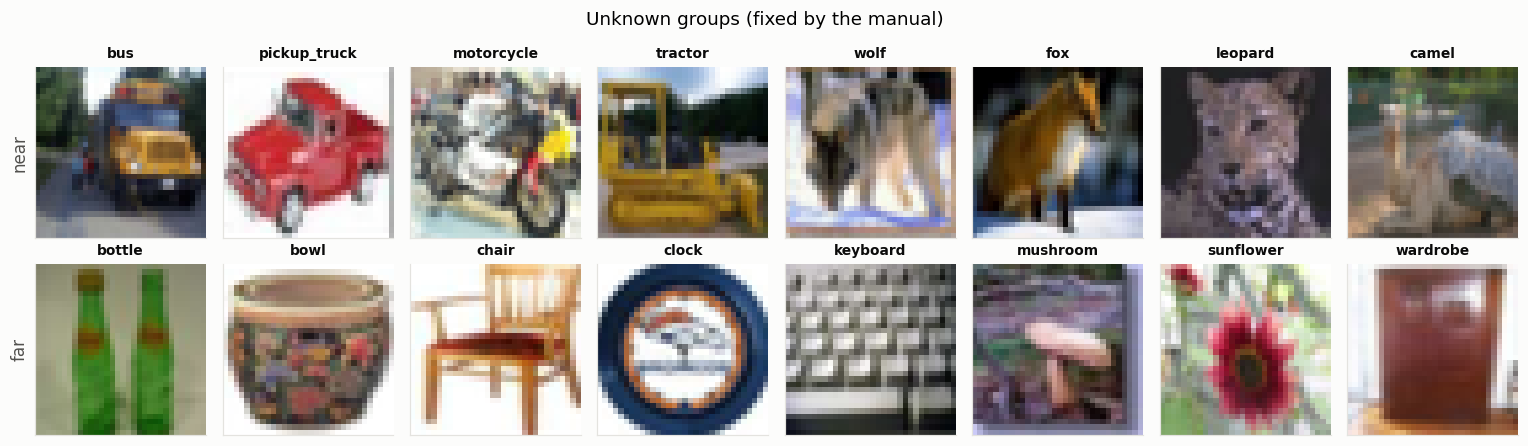

In [3]:
from torchvision import datasets
from task4_open_set.src.data import CIFAR100_ROOT
datasets.CIFAR100(CIFAR100_ROOT, train=False, download=True)
near_ds, far_ds, c100_classes = get_cifar100_unknowns()
from task4_open_set.src.data import get_cifar10
test_ds_plain = get_cifar10()[3]
print(f'near: {len(near_ds)} images, far: {len(far_ds)} images')
mean, std = torch.tensor(MEAN).view(3, 1, 1), torch.tensor(STD).view(3, 1, 1)
fig, axes = plt.subplots(2, 8, figsize=(14, 4.2))
for r, (ds, names) in enumerate([(near_ds, NEAR_UNKNOWNS), (far_ds, FAR_UNKNOWNS)]):
    tg = np.array(ds.dataset.targets)[ds.indices]
    for c, nm in enumerate(names):
        i = int(np.where(tg == c100_classes.index(nm))[0][0])
        axes[r, c].imshow((ds[i][0] * std + mean).clamp(0, 1).permute(1, 2, 0)); axes[r, c].set_title(nm, fontsize=9)
        axes[r, c].set_xticks([]); axes[r, c].set_yticks([]); axes[r, c].grid(False)
    axes[r, 0].set_ylabel(['near', 'far'][r], fontsize=11)
fig.suptitle('Unknown groups (fixed by the manual)', fontsize=12); fig.tight_layout()
save_show(fig, os.path.join(RES, 'unknown_groups_gallery.png'))

## 2. Vanilla outputs: cached known splits + unknowns

In [4]:
K = np.load(os.path.join(CACHE, 'vanilla_known.npz'))
model = ResNetCIFAR(num_classes=10).to(device)
model.load_state_dict(torch.load(os.path.join(CKPT, 'vanilla.pth'), map_location=device, weights_only=True))
U = {g: extract_outputs(model, make_loader(ds, False, 512), device) for g, ds in [('near', near_ds), ('far', far_ds)]}
np.savez_compressed(os.path.join(CACHE, 'vanilla_unknown.npz'), **{f'{g}_{k}': v for g, o in U.items() for k, v in o.items()})
L = {'train': K['train_logits'], 'val': K['val_logits'], 'test': K['test_logits'], 'near': U['near']['logits'], 'far': U['far']['logits']}
Fe = {'train': K['train_feats'], 'val': K['val_feats'], 'test': K['test_feats'], 'near': U['near']['feats'], 'far': U['far']['feats']}
csa = (K['test_logits'].argmax(1) == K['test_labels']).mean()
print(f'Vanilla CSA {100*csa:.2f}%')

Vanilla CSA 94.81%


## 3. Scores and the comparison table

In [5]:
means, prec = fit_mahalanobis(K['train_feats'], K['train_labels'], num_classes=10, reg=1e-6)
S = {split: all_posthoc_scores(L[split], Fe[split], means, prec) for split in ['val', 'test', 'near', 'far']}
SCORES = ['MSP', 'MLS', 'Energy', 'Mahalanobis']
rep = pd.DataFrame({s: osr_report(S['val'][s], S['test'][s], S['near'][s], S['far'][s], csa) for s in SCORES}).T
rep.index.name = 'Vanilla score'
rep.to_csv(os.path.join(RES, 'posthoc_scores_table.csv'))
rep.drop(columns=['CSA (%)']).round(2)

,AUROC near,AUROC far,AUROC all,tau,Known test accept (%),Near reject (%),Far reject (%),FPR@95 near (%),FPR@95 far (%),FPR@95 all (%)
Vanilla score,,,,,,,,,,
MSP,81.83,89.57,85.70,0.16,94.66,31.75,44.38,68.25,55.62,61.94
MLS,80.27,89.48,84.87,-5.84,94.71,35.00,53.50,65.00,46.50,55.75
Energy,80.27,89.54,84.91,-6.03,94.58,35.00,55.00,65.00,45.00,55.00
Mahalanobis,80.06,91.36,85.71,2812.01,94.62,29.75,51.25,70.25,48.75,59.50


## 4. Score distributions and ROC curves (MSP, MLS, Mahalanobis)
Top row: score histograms for known test, near and far images, with the validation-calibrated threshold τ (dashed). Bottom row: ROC curves (unknown = positive).

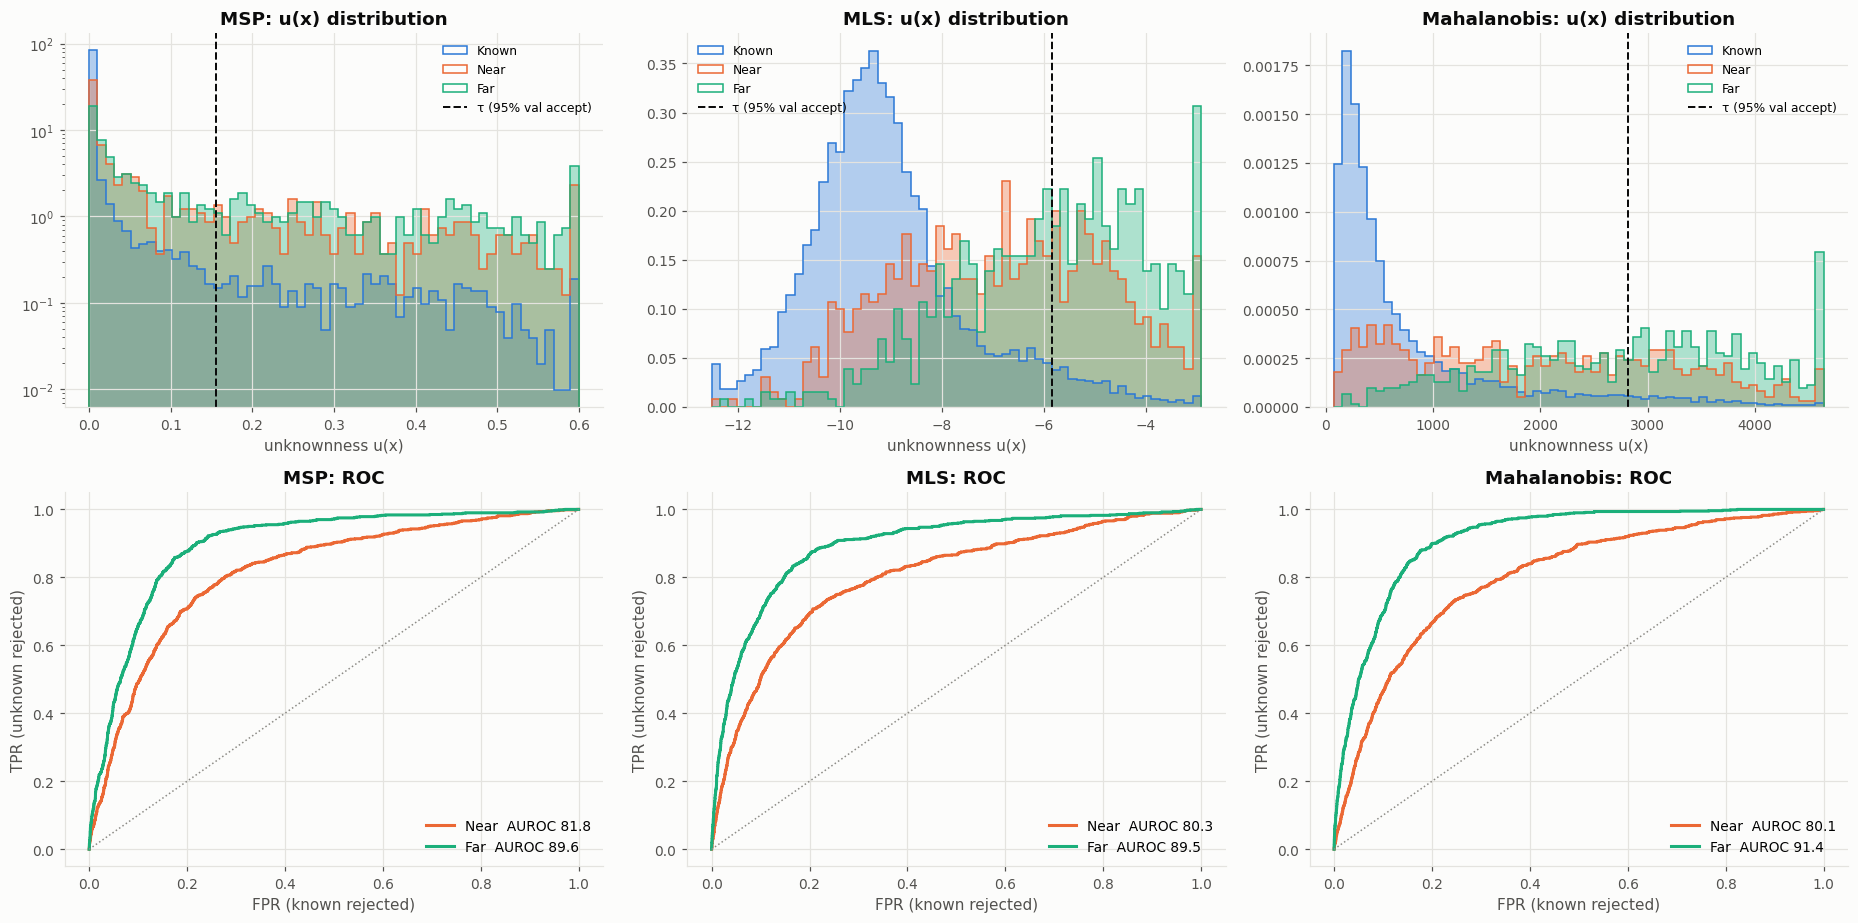

In [6]:
fig, ax = plt.subplots(2, 3, figsize=(17, 8.5))
for j, s in enumerate(['MSP', 'MLS', 'Mahalanobis']):
    a = ax[0, j]
    vals = np.concatenate([S['test'][s], S['near'][s], S['far'][s]])
    lo, hi = np.percentile(vals, 0.5), np.percentile(vals, 99.5)
    bins = np.linspace(lo, hi, 60)
    for g, key in [('Known', 'test'), ('Near', 'near'), ('Far', 'far')]:
        a.hist(np.clip(S[key][s], lo, hi), bins=bins, histtype='stepfilled', alpha=0.35, color=GROUP_COLORS[g], density=True)
        a.hist(np.clip(S[key][s], lo, hi), bins=bins, histtype='step', lw=1.8, color=GROUP_COLORS[g], density=True, label=g)
    a.axvline(rep.loc[s, 'tau'], color='#0b0b0b', ls='--', lw=1.3, label='τ (95% val accept)')
    if s == 'MSP': a.set_yscale('log')
    a.set_title(f'{s}: u(x) distribution'); a.set_xlabel('unknownness u(x)'); a.legend(fontsize=8)
    b = ax[1, j]
    for g, key in [('Near', 'near'), ('Far', 'far')]:
        fpr, tpr = roc(S['test'][s], S[key][s])
        b.plot(fpr, tpr, color=GROUP_COLORS[g], label=f"{g}  AUROC {rep.loc[s, f'AUROC {key}']:.1f}")
    b.plot([0, 1], [0, 1], color=NEUTRAL, ls=':', lw=1)
    b.set_xlabel('FPR (known rejected)'); b.set_ylabel('TPR (unknown rejected)'); b.set_title(f'{s}: ROC'); b.legend(loc='lower right')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'posthoc_scores_distributions_roc.png'))

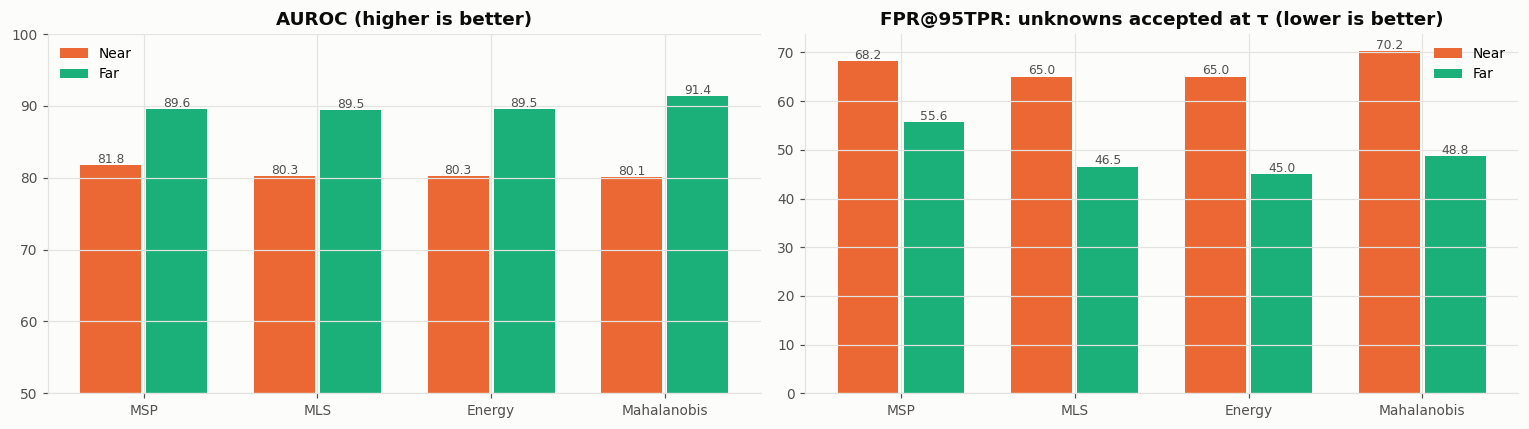

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(4); w = 0.38
for k, (g, key) in enumerate([('Near', 'near'), ('Far', 'far')]):
    b = ax[0].bar(x + (k - 0.5) * w, rep[f'AUROC {key}'], w * 0.92, color=GROUP_COLORS[g], label=g)
    for bb in b: ax[0].text(bb.get_x() + bb.get_width() / 2, bb.get_height() + 0.3, f'{bb.get_height():.1f}', ha='center', fontsize=8, color=INK_2)
    b = ax[1].bar(x + (k - 0.5) * w, rep[f'FPR@95 {key} (%)'], w * 0.92, color=GROUP_COLORS[g], label=g)
    for bb in b: ax[1].text(bb.get_x() + bb.get_width() / 2, bb.get_height() + 0.5, f'{bb.get_height():.1f}', ha='center', fontsize=8, color=INK_2)
ax[0].set_ylim(50, 100); ax[0].set_title('AUROC (higher is better)'); ax[1].set_title('FPR@95TPR: unknowns accepted at τ (lower is better)')
for a in ax: a.set_xticks(x); a.set_xticklabels(SCORES); a.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'posthoc_scores_bars.png'))

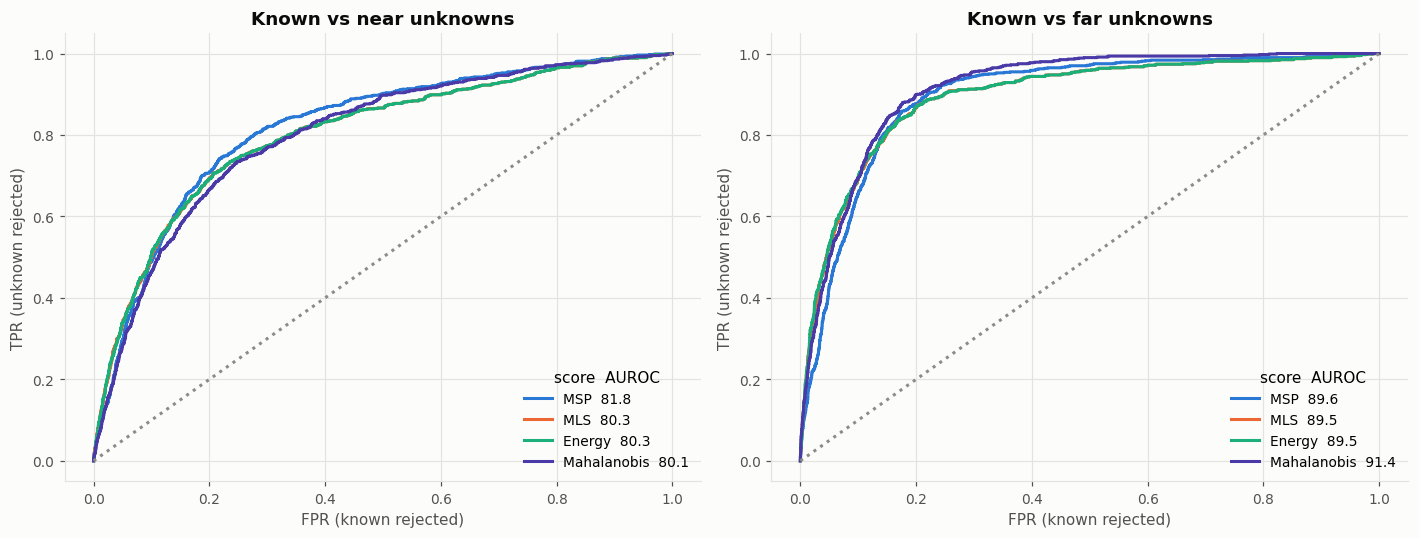

In [8]:
# ROC curves of all four scores on one axis per unknown group
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, key in zip(axes, ['near', 'far']):
    for sname in SCORES:
        fpr, tpr = roc(S['test'][sname], S[key][sname])
        ax.plot(fpr, tpr, color=color_of(sname), label=f"{sname}  {rep.loc[sname, f'AUROC {key}']:.1f}")
    ax.plot([0, 1], [0, 1], ':', color=NEUTRAL); ax.set_xlabel('FPR (known rejected)'); ax.set_ylabel('TPR (unknown rejected)')
    ax.set_title(f'Known vs {key} unknowns'); ax.legend(loc='lower right', title='score  AUROC')
fig.tight_layout(); save_show(fig, os.path.join(RES, 'posthoc_roc_all_scores.png'))

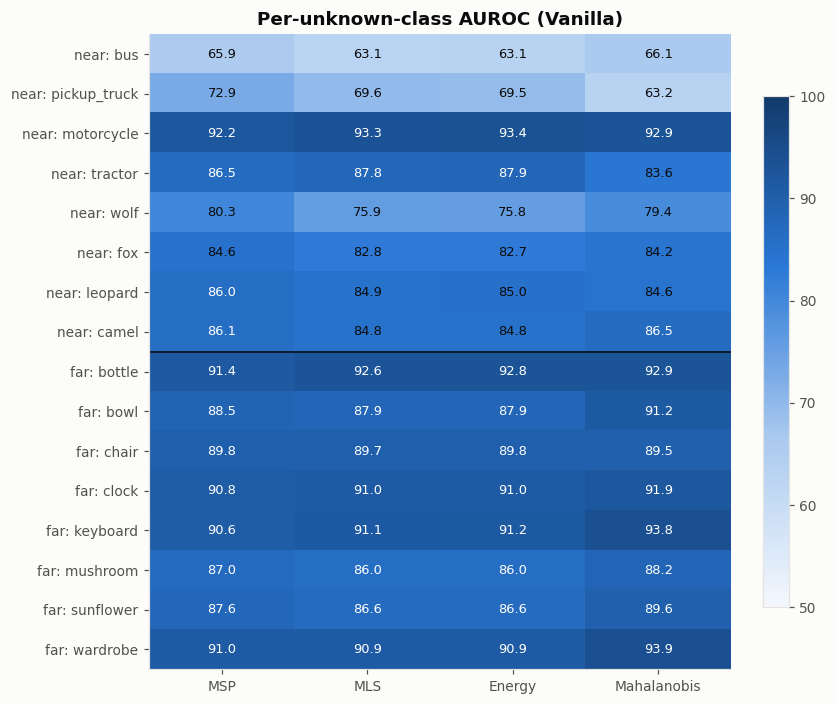

,bus,pickup_truck,motorcycle,tractor,wolf,fox,leopard,camel,bottle,bowl,chair,clock,keyboard,mushroom,sunflower,wardrobe
MSP,65.9,72.9,92.2,86.5,80.3,84.6,86.0,86.1,91.4,88.5,89.8,90.8,90.6,87.0,87.6,91.0
MLS,63.1,69.6,93.3,87.8,75.9,82.8,84.9,84.8,92.6,87.9,89.7,91.0,91.1,86.0,86.6,90.9
Energy,63.1,69.5,93.4,87.9,75.8,82.7,85.0,84.8,92.8,87.9,89.8,91.0,91.2,86.0,86.6,90.9
Mahalanobis,66.1,63.2,92.9,83.6,79.4,84.2,84.6,86.5,92.9,91.2,89.5,91.9,93.8,88.2,89.6,93.9


In [9]:
# AUROC for every individual unknown class: which unknowns are hard for which signal?
near_cls = np.array([c100_classes[t] for t in np.array(near_ds.dataset.targets)[near_ds.indices]])
far_cls = np.array([c100_classes[t] for t in np.array(far_ds.dataset.targets)[far_ds.indices]])
pca = pd.DataFrame({sname: {**per_class_auroc(S['test'][sname], S['near'][sname], near_cls), **per_class_auroc(S['test'][sname], S['far'][sname], far_cls)}
                    for sname in SCORES}).loc[NEAR_UNKNOWNS + FAR_UNKNOWNS]
fig, a = plt.subplots(figsize=(7.5, 7.5))
im = a.imshow(pca.values, cmap=SEQ_CMAP, vmin=50, vmax=100, aspect='auto')
for i in range(pca.shape[0]):
    for j in range(4): a.text(j, i, f'{pca.values[i, j]:.1f}', ha='center', va='center', fontsize=8.5, color='white' if pca.values[i, j] > 85 else '#0b0b0b')
a.set_xticks(range(4)); a.set_xticklabels(SCORES); a.set_yticks(range(16)); a.set_yticklabels([f'near: {c}' for c in NEAR_UNKNOWNS] + [f'far: {c}' for c in FAR_UNKNOWNS])
a.axhline(7.5, color='#0b0b0b', lw=1); a.grid(False); a.set_title('Per-unknown-class AUROC (Vanilla)'); fig.colorbar(im, ax=a, fraction=0.04)
save_show(fig, os.path.join(RES, 'posthoc_per_class_auroc.png'))
pca.round(1).T

## 5. Where do the scores agree and disagree?
Spearman rank correlation of the four scores over all known-test and unknown images, and MLS vs Mahalanobis per image. Disagreements show when logit magnitude and feature distance carry different information.

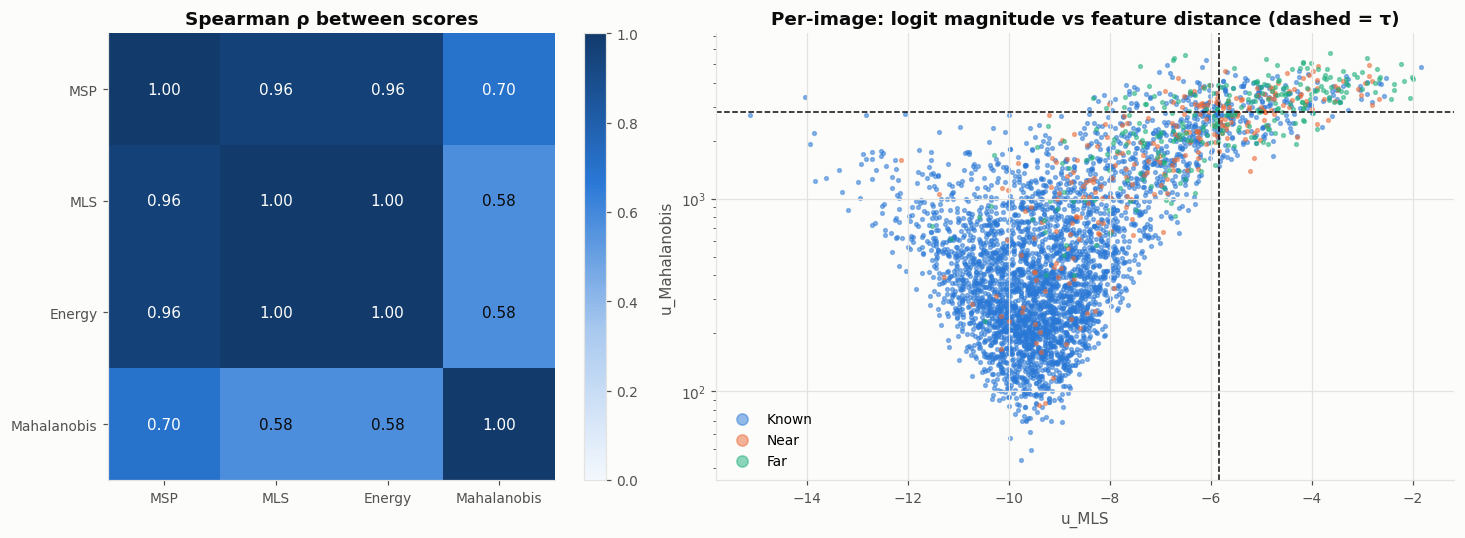

In [10]:
allu = {s: np.concatenate([S['test'][s], S['near'][s], S['far'][s]]) for s in SCORES}
grp = np.array(['Known'] * len(S['test']['MLS']) + ['Near'] * 800 + ['Far'] * 800)
rho = pd.DataFrame([[spearmanr(allu[a], allu[b])[0] for b in SCORES] for a in SCORES], index=SCORES, columns=SCORES)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1, 1.3]})
im = a1.imshow(rho.values, cmap=SEQ_CMAP, vmin=0, vmax=1)
for i in range(4):
    for j in range(4): a1.text(j, i, f'{rho.values[i, j]:.2f}', ha='center', va='center', color='white' if rho.values[i, j] > 0.6 else '#0b0b0b')
a1.set_xticks(range(4)); a1.set_xticklabels(SCORES); a1.set_yticks(range(4)); a1.set_yticklabels(SCORES); a1.grid(False)
a1.set_title('Spearman ρ between scores'); fig.colorbar(im, ax=a1, fraction=0.046)
sub = np.random.RandomState(SEED).choice(len(grp), 4000, replace=False)
for g in ['Known', 'Near', 'Far']:
    s = sub[grp[sub] == g]
    a2.scatter(allu['MLS'][s], allu['Mahalanobis'][s], s=6, alpha=0.5, color=GROUP_COLORS[g], label=g)
a2.axvline(rep.loc['MLS', 'tau'], color='#0b0b0b', ls='--', lw=1); a2.axhline(rep.loc['Mahalanobis', 'tau'], color='#0b0b0b', ls='--', lw=1)
a2.set_xlabel('u_MLS'); a2.set_ylabel('u_Mahalanobis'); a2.set_yscale('log'); a2.set_title('Per-image: logit magnitude vs feature distance (dashed = τ)'); a2.legend(markerscale=3)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'posthoc_scores_agreement.png'))

In [11]:
# Agreement of accept/reject decisions at each score's own τ, on unknown images
acc_dec = {s: np.concatenate([S['near'][s], S['far'][s]]) <= rep.loc[s, 'tau'] for s in SCORES}
agree = pd.DataFrame([[100 * (acc_dec[a] == acc_dec[b]).mean() for b in SCORES] for a in SCORES], index=SCORES, columns=SCORES)
only = {f'accepted by {a} but rejected by {b}': int((acc_dec[a] & ~acc_dec[b]).sum()) for a in SCORES for b in SCORES if a != b and {a, b} in ({'MLS', 'Mahalanobis'}, {'MSP', 'MLS'}, {'MSP', 'Mahalanobis'})}
print('decision agreement on unknowns (%):'); display(agree.round(1)); print(only)

decision agreement on unknowns (%):


,MSP,MLS,Energy,Mahalanobis
MSP,100.0,85.4,82.9,89.3
MLS,85.4,100.0,97.5,81.1
Energy,82.9,97.5,100.0,79.5
Mahalanobis,89.3,81.1,79.5,100.0


{'accepted by MSP but rejected by MLS': 166, 'accepted by MSP but rejected by Mahalanobis': 105, 'accepted by MLS but rejected by MSP': 67, 'accepted by MLS but rejected by Mahalanobis': 121, 'accepted by Mahalanobis but rejected by MSP': 66, 'accepted by Mahalanobis but rejected by MLS': 181}


### What the scores see, as pictures
For MLS and Mahalanobis: the 8 unknowns that look **most known** (lowest $u$; each would be accepted), and the 8 known test images that look **most unknown** (highest $u$; each would be rejected).

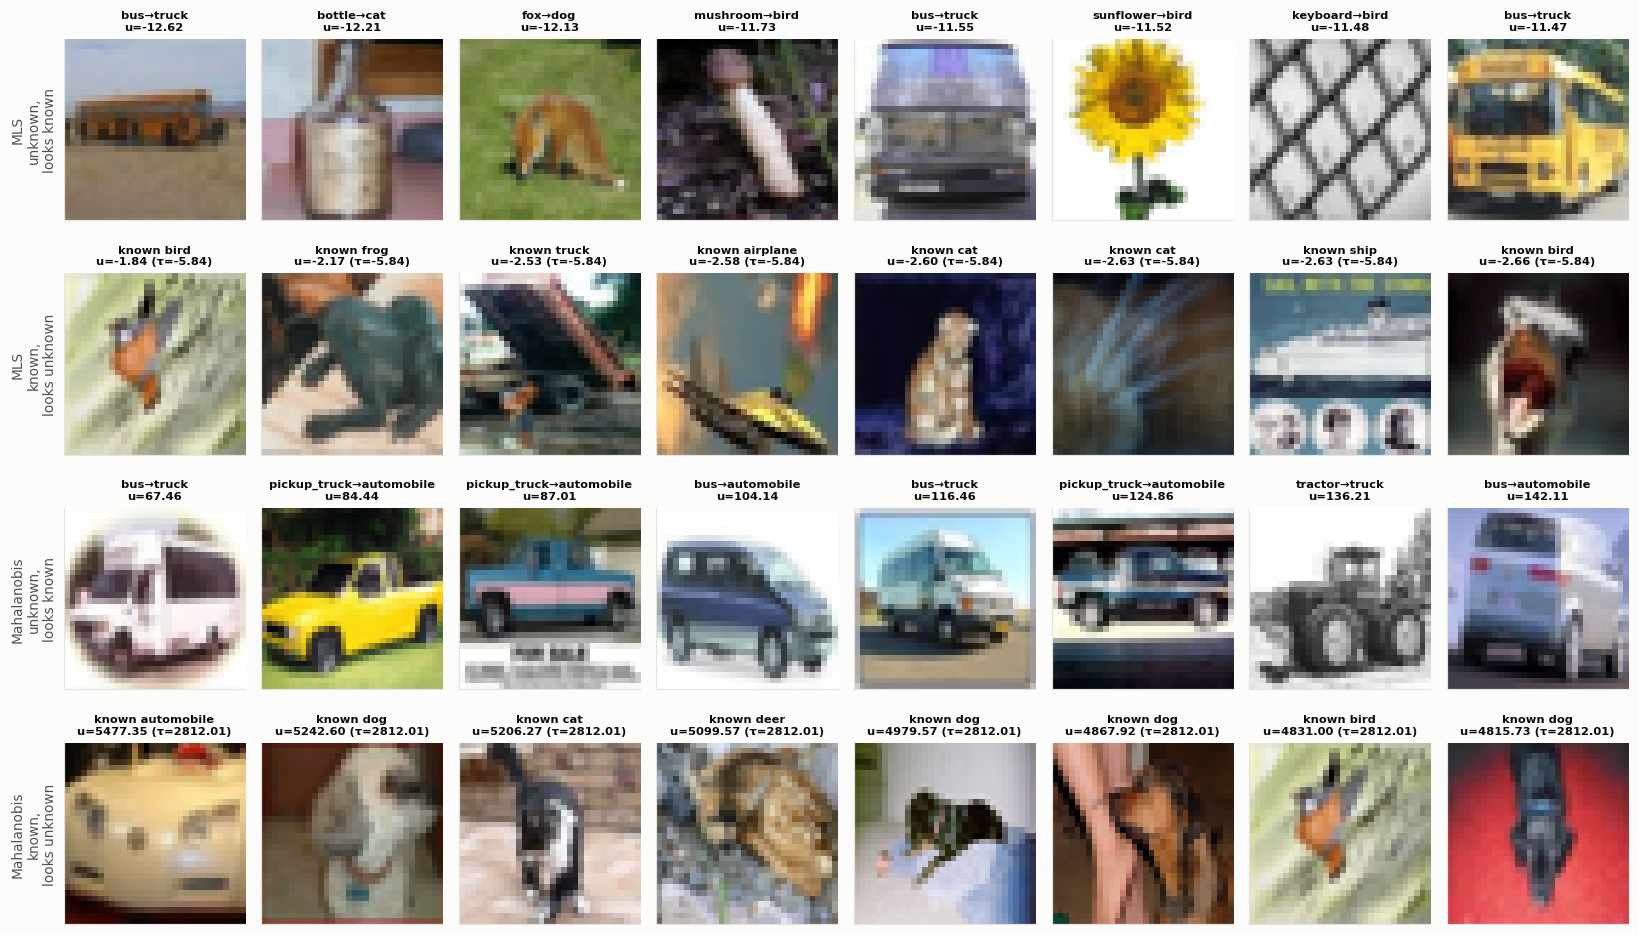

In [12]:
unk_imgs = [near_ds[i][0] for i in range(len(near_ds))] + [far_ds[i][0] for i in range(len(far_ds))]
unk_cls = np.concatenate([near_cls, far_cls]); unk_pred = np.concatenate([L['near'].argmax(1), L['far'].argmax(1)])
fig, axes = plt.subplots(4, 8, figsize=(15, 8.8))
for r, sname in enumerate(['MLS', 'Mahalanobis']):
    uu = np.concatenate([S['near'][sname], S['far'][sname]]); tau = rep.loc[sname, 'tau']
    for c, i in enumerate(np.argsort(uu)[:8]):
        ax = axes[2 * r, c]; ax.imshow(denorm(unk_imgs[i])); ax.set_title(f'{unk_cls[i]}→{CIFAR10_CLASSES[unk_pred[i]]}\nu={uu[i]:.2f}', fontsize=7.5)
    ut = S['test'][sname]
    for c, i in enumerate(np.argsort(-ut)[:8]):
        ax = axes[2 * r + 1, c]; x_, y_ = test_ds_plain[int(i)]; ax.imshow(denorm(x_))
        ax.set_title(f'known {CIFAR10_CLASSES[y_]}\nu={ut[i]:.2f} (τ={tau:.2f})', fontsize=7.5)
    axes[2 * r, 0].set_ylabel(f'{sname}\nunknown,\nlooks known', fontsize=9); axes[2 * r + 1, 0].set_ylabel(f'{sname}\nknown,\nlooks unknown', fontsize=9)
for a in axes.ravel(): a.set_xticks([]); a.set_yticks([]); a.grid(False)
fig.tight_layout(); save_show(fig, os.path.join(RES, 'posthoc_extreme_examples.png'))

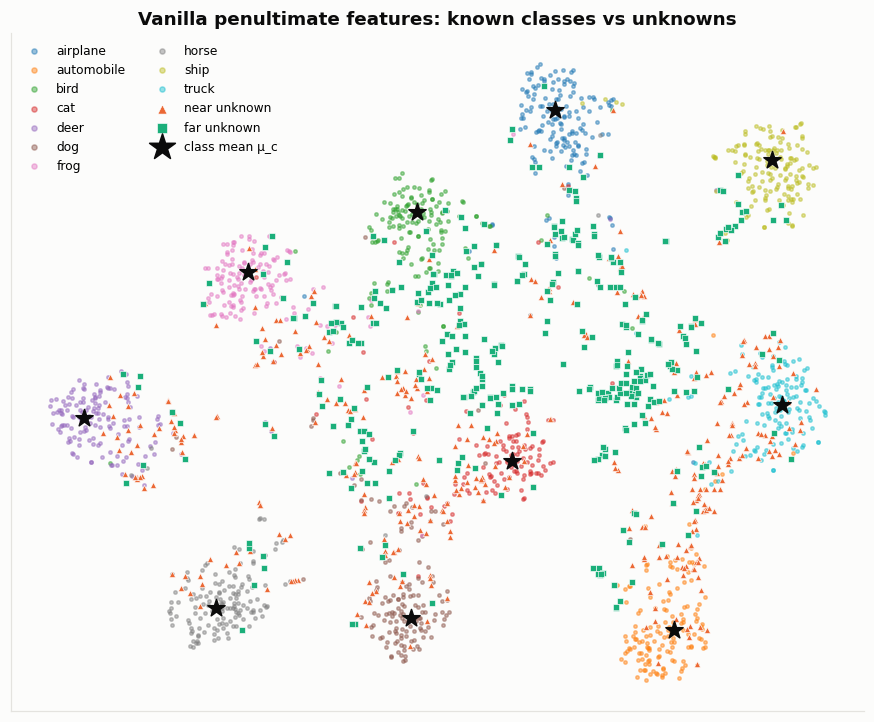

In [13]:
# Feature space: known test (by class) with near/far unknowns overlaid, one t-SNE (seed 6304)
rng = np.random.RandomState(SEED)
kt = rng.choice(len(Fe['test']), 1500, replace=False); nt = rng.choice(800, 400, replace=False); ft = rng.choice(800, 400, replace=False)
X = np.concatenate([Fe['test'][kt], Fe['near'][nt], Fe['far'][ft], means])
E = TSNE(n_components=2, perplexity=30, init='pca', random_state=SEED).fit_transform(X)
yk = K['test_labels'][kt]; cmap10 = plt.get_cmap('tab10')
fig, a = plt.subplots(figsize=(10, 8))
for c in range(10):
    s = yk == c; a.scatter(E[:1500][s, 0], E[:1500][s, 1], s=5, alpha=0.45, color=cmap10(c), label=CIFAR10_CLASSES[c])
a.scatter(E[1500:1900, 0], E[1500:1900, 1], s=16, marker='^', color=GROUP_COLORS['Near'], edgecolors='white', linewidths=0.4, label='near unknown')
a.scatter(E[1900:2300, 0], E[1900:2300, 1], s=16, marker='s', color=GROUP_COLORS['Far'], edgecolors='white', linewidths=0.4, label='far unknown')
a.scatter(E[2300:, 0], E[2300:, 1], s=140, marker='*', color='#0b0b0b', label='class mean μ_c')
a.set_xticks([]); a.set_yticks([]); a.set_title('Vanilla penultimate features: known classes vs unknowns'); a.legend(fontsize=8, ncol=2, markerscale=1.5)
save_show(fig, os.path.join(RES, 'posthoc_feature_tsne.png'))

## 6. Which unknown classes get accepted, and which known labels absorb them? (Vanilla + MLS)

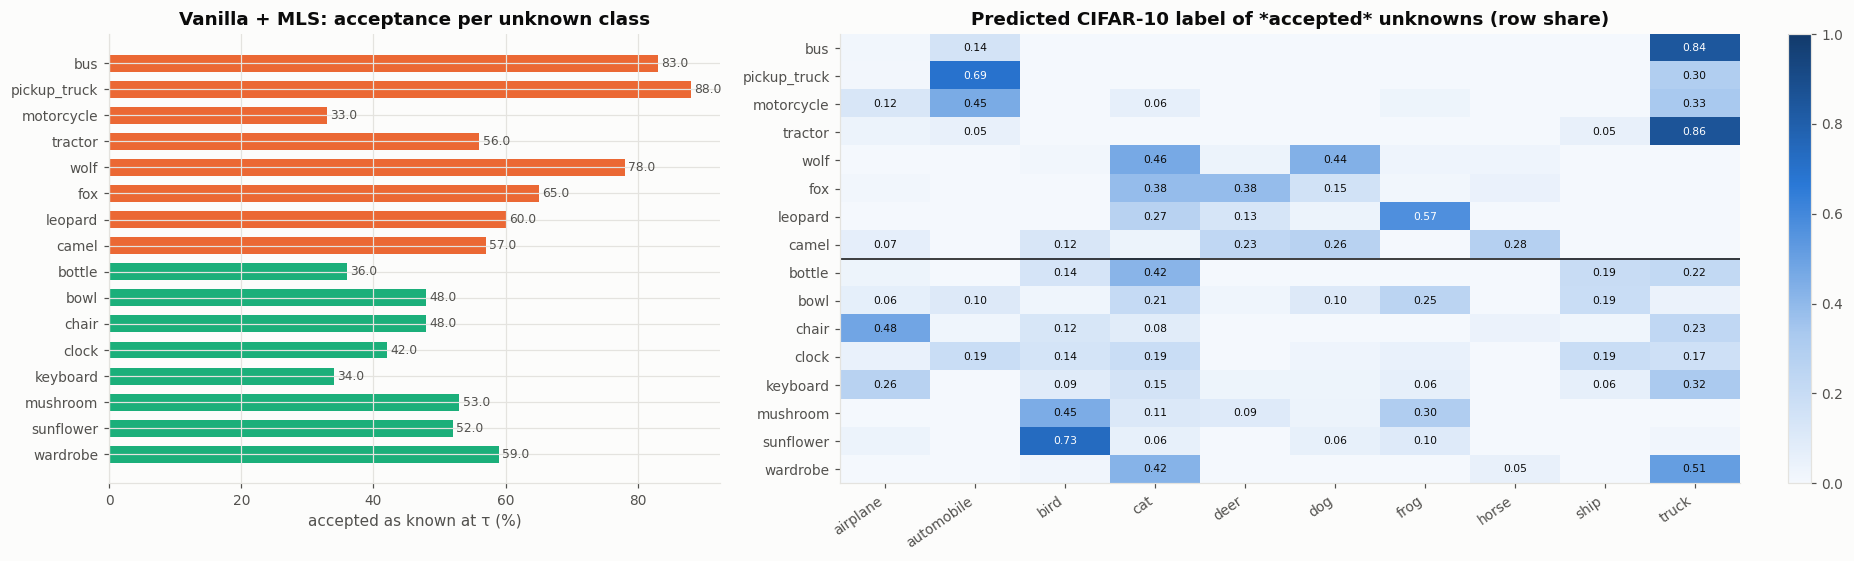

group         near                                                            \
class          bus pickup_truck motorcycle tractor  wolf   fox leopard camel   
accepted (%)  83.0         88.0       33.0    56.0  78.0  65.0    60.0  57.0   

group           far                                                         
class        bottle  bowl chair clock keyboard mushroom sunflower wardrobe  
accepted (%)   36.0  48.0  48.0  42.0     34.0     53.0      52.0     59.0

In [14]:
u_tau = rep.loc['MLS', 'tau']
rows, absorb = [], {}
for g, ds, names in [('near', near_ds, NEAR_UNKNOWNS), ('far', far_ds, FAR_UNKNOWNS)]:
    tg = np.array(ds.dataset.targets)[ds.indices]; u = S[g]['MLS']; pred = L[g].argmax(1)
    for nm in names:
        s = tg == c100_classes.index(nm); acc = u[s] <= u_tau
        rows.append({'group': g, 'class': nm, 'accepted (%)': 100 * acc.mean()})
        absorb[nm] = np.bincount(pred[s][acc], minlength=10) / max(1, acc.sum())
acc_tab = pd.DataFrame(rows).set_index(['group', 'class'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(17, 5.2), gridspec_kw={'width_ratios': [1, 1.6]})
cols = [GROUP_COLORS['Near'] if g == 'near' else GROUP_COLORS['Far'] for g, _ in acc_tab.index]
b = a1.barh([c for _, c in acc_tab.index][::-1], acc_tab['accepted (%)'].values[::-1], color=cols[::-1], height=0.65)
for bb in b: a1.text(bb.get_width() + 0.5, bb.get_y() + bb.get_height() / 2, f'{bb.get_width():.1f}', va='center', fontsize=8, color=INK_2)
a1.set_xlabel('accepted as known at τ (%)'); a1.set_title('Vanilla + MLS: acceptance per unknown class')
A = np.array([absorb[n] for n in NEAR_UNKNOWNS + FAR_UNKNOWNS])
im = a2.imshow(A, cmap=SEQ_CMAP, vmin=0, vmax=1, aspect='auto')
for i in range(A.shape[0]):
    for j in range(10):
        if A[i, j] >= 0.05: a2.text(j, i, f'{A[i, j]:.2f}', ha='center', va='center', fontsize=7, color='white' if A[i, j] > 0.55 else '#0b0b0b')
a2.set_xticks(range(10)); a2.set_xticklabels(CIFAR10_CLASSES, rotation=35, ha='right'); a2.set_yticks(range(16)); a2.set_yticklabels(NEAR_UNKNOWNS + FAR_UNKNOWNS)
a2.axhline(7.5, color='#0b0b0b', lw=1); a2.grid(False); a2.set_title('Predicted CIFAR-10 label of *accepted* unknowns (row share)')
fig.colorbar(im, ax=a2, fraction=0.03); fig.tight_layout(); save_show(fig, os.path.join(RES, 'posthoc_mls_acceptance_by_class.png'))
acc_tab.round(1).T